# Project Overview

The objective of this analysis is to explore factors that influence medical insurance charges and prepare the dataset for downstream predictive modeling. This EDA focuses on understanding the structure of the data, identifying quality issues, examining feature distributions, and highlighting patterns that may help explain insurance cost variation.

## Dataset Description

The dataset contains demographic and health-related attributes of individuals, including:

- Age: Age of the individual
- Sex: Gender
- BMI: Body Mass Index
- Children: Number of dependents
- Smoker: Smoking status
- Region: Residential region
- Charges: Medical insurance cost

The target variable for modeling will be derived from the `charges` column.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)

candidate_roots = [Path.cwd(), Path.cwd().parent]
PROJECT_ROOT = next((root for root in candidate_roots if (root / "data/raw/insurance.csv").exists()), None)

if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not find data/raw/insurance.csv from the current notebook location.")

RAW_PATH = PROJECT_ROOT / "data/raw/insurance.csv"
CLEAN_PATH = PROJECT_ROOT / "data/processed/clean_data.csv"

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw data path: {RAW_PATH}")
print(f"Clean data path: {CLEAN_PATH}")

Project root: /Users/rebeccarosettenanfuka/Desktop/MY-_PROJECTS/InsureRisk
Raw data path: /Users/rebeccarosettenanfuka/Desktop/MY-_PROJECTS/InsureRisk/data/raw/insurance.csv
Clean data path: /Users/rebeccarosettenanfuka/Desktop/MY-_PROJECTS/InsureRisk/data/processed/clean_data.csv


## Load Data

In [3]:
df = pd.read_csv(RAW_PATH)
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
print(f"Rows, columns: {df.shape}")
df.info()

Rows, columns: (1338, 7)
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


## Data Quality Checks

In [5]:
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2),
    "dtype": df.dtypes.astype(str)
})
missing_summary

,missing_count,missing_percent,dtype
age,0,0.0,int64
sex,0,0.0,str
bmi,0,0.0,float64
children,0,0.0,int64
smoker,0,0.0,str
region,0,0.0,str
charges,0,0.0,float64


In [6]:
duplicate_count = int(df.duplicated().sum())
print(f"Duplicate rows: {duplicate_count}")

if duplicate_count:
    display(df[df.duplicated()].head())

Duplicate rows: 1


,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


In [7]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,1338.0,NaN,NaN,NaN,39.207025,14.04996,18.0,27.0,39.0,51.0,64.0
sex,1338,2,male,676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,1338.0,NaN,NaN,NaN,30.663397,6.098187,15.96,26.29625,30.4,34.69375,53.13
children,1338.0,NaN,NaN,NaN,1.094918,1.205493,0.0,0.0,1.0,2.0,5.0
smoker,1338,2,no,1064,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,1338,4,southeast,364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
charges,1338.0,NaN,NaN,NaN,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


## Univariate Analysis

In [8]:
numeric_columns = ["age", "bmi", "children", "charges"]
categorical_columns = ["sex", "smoker", "region"]

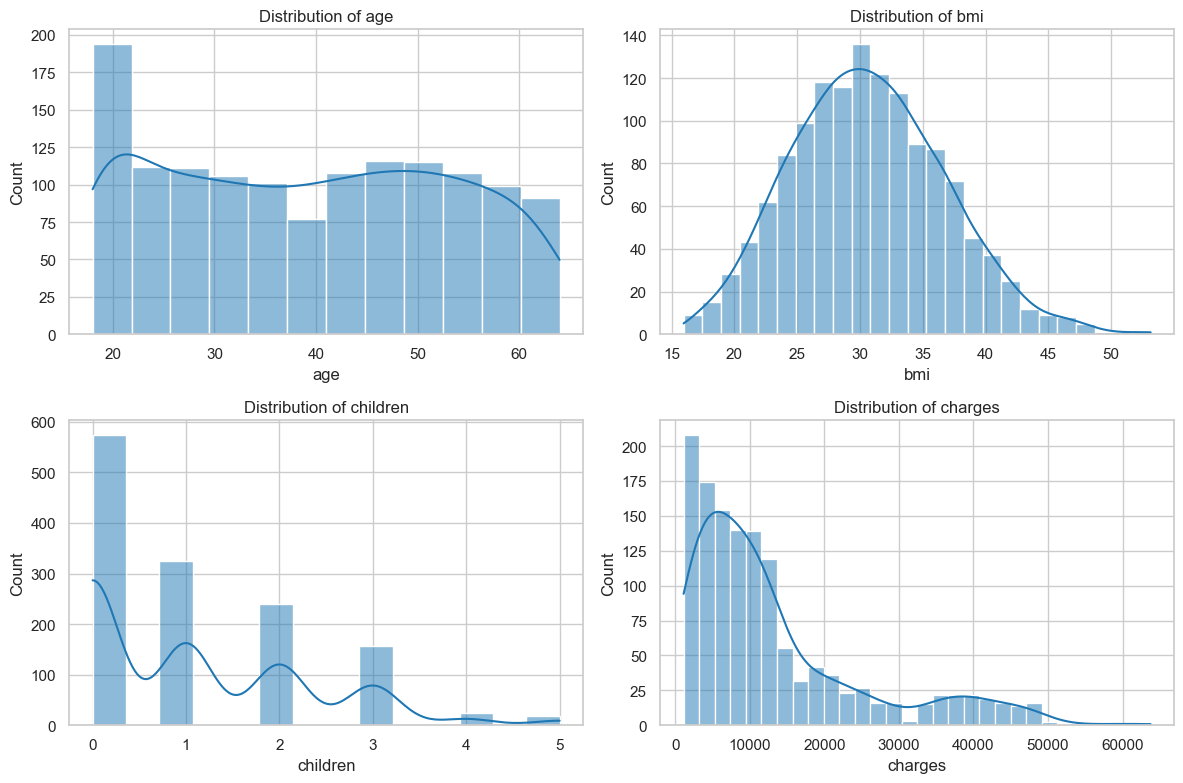

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, column in zip(axes.flatten(), numeric_columns):
    sns.histplot(df[column], kde=True, ax=ax, color="#1f77b4")
    ax.set_title(f"Distribution of {column}")

plt.tight_layout()

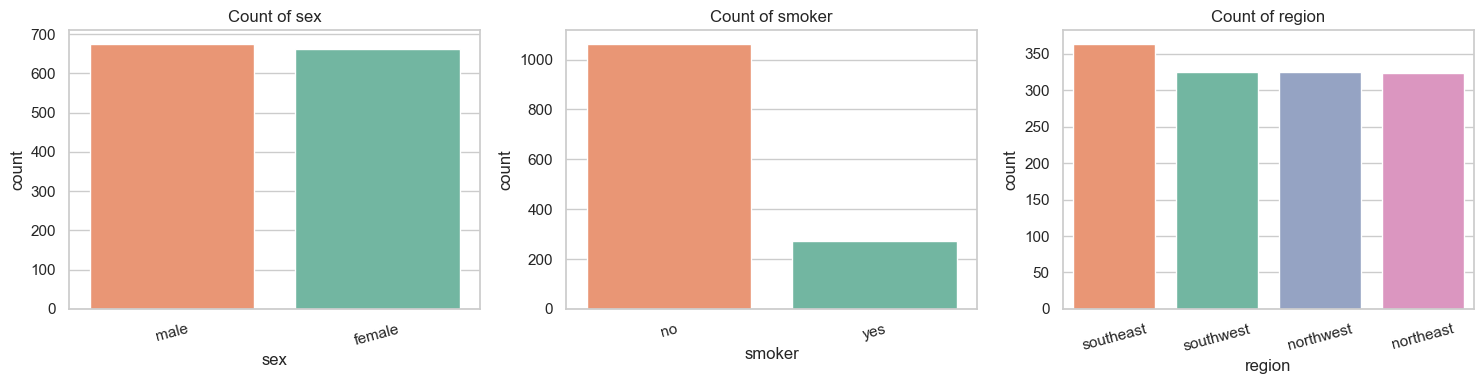

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, column in zip(axes, categorical_columns):
    order = df[column].value_counts().index
    sns.countplot(data=df, x=column, order=order, ax=ax, hue=column, palette="Set2", legend=False)
    ax.set_title(f"Count of {column}")
    ax.tick_params(axis="x", rotation=15)

plt.tight_layout()

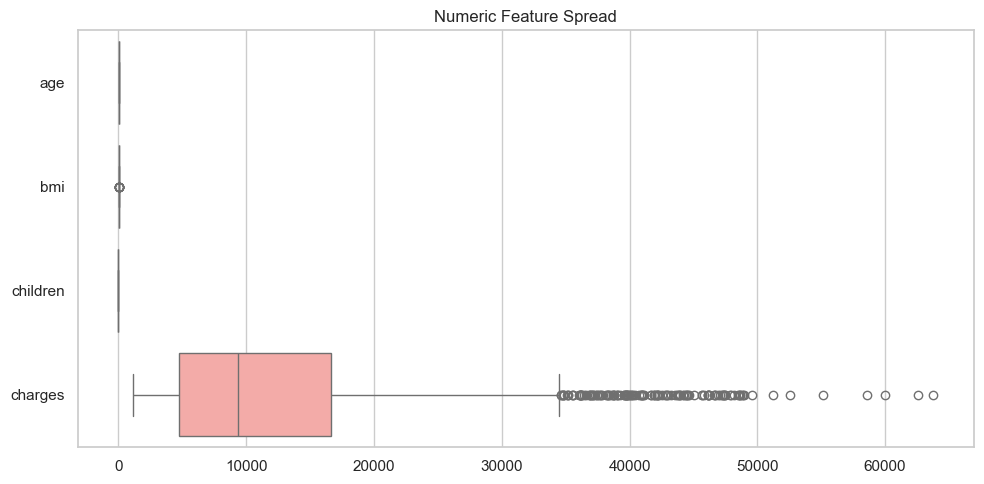

In [11]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[numeric_columns], orient="h", palette="pastel")
plt.title("Numeric Feature Spread")
plt.tight_layout()

Smokers exhibit significantly higher insurance charges compared to non-smokers. The distribution suggests that smoking is a major factor influencing insurance costs.

## Visual Proof of Key Drivers

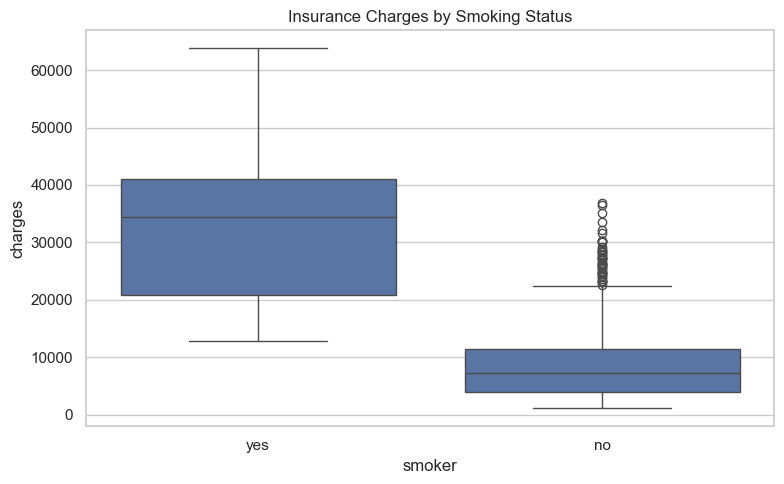

In [12]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="smoker", y="charges", data=df)
plt.title("Insurance Charges by Smoking Status")
plt.tight_layout()
plt.show()

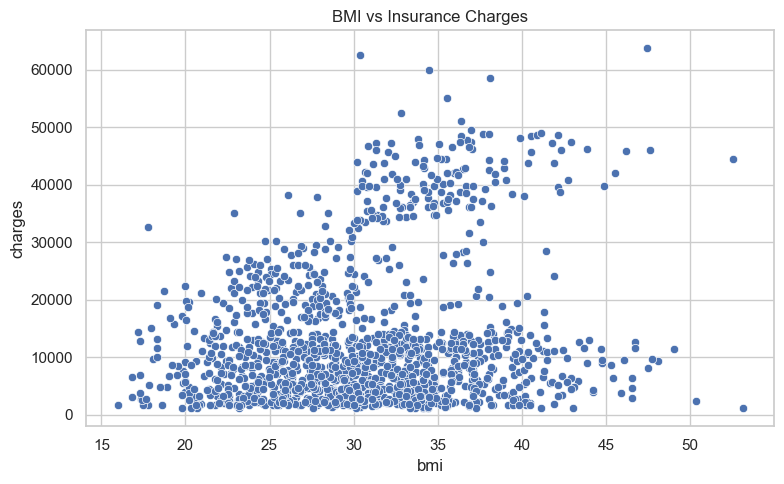

In [13]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x="bmi", y="charges", data=df)
plt.title("BMI vs Insurance Charges")
plt.tight_layout()
plt.show()

/var/folders/fg/nsxxd2jx70z7bfc7lh6dcfl80000gn/T/ipykernel_69892/685165136.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="smoker", y="charges", palette="Set1", ax=axes[1])


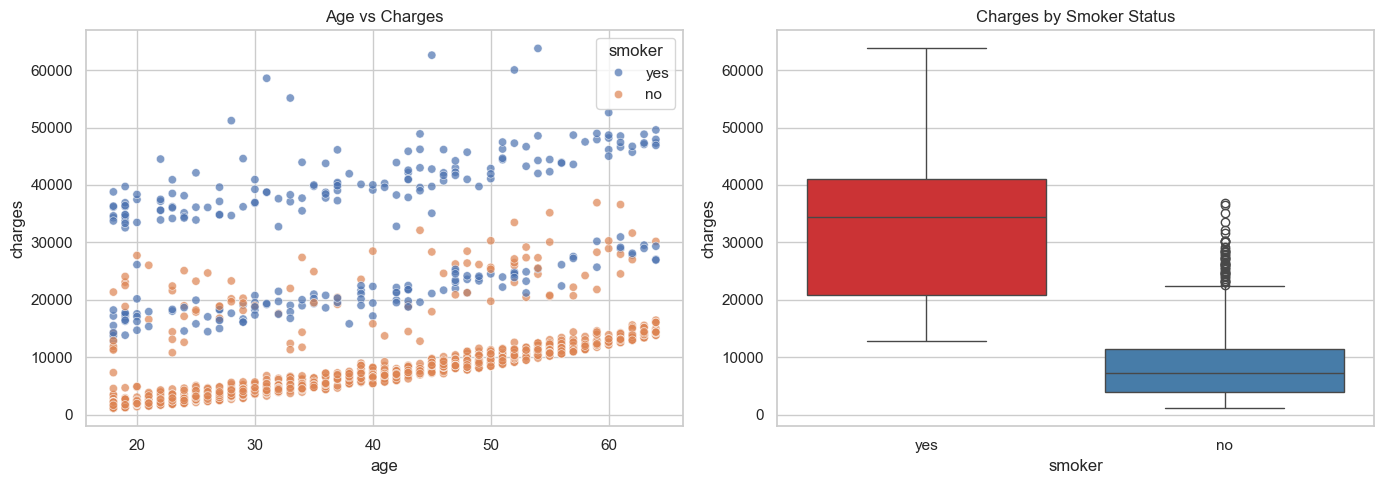

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x="age", y="charges", hue="smoker", alpha=0.7, ax=axes[0])
axes[0].set_title("Age vs Charges")

sns.boxplot(data=df, x="smoker", y="charges", palette="Set1", ax=axes[1])
axes[1].set_title("Charges by Smoker Status")

plt.tight_layout()

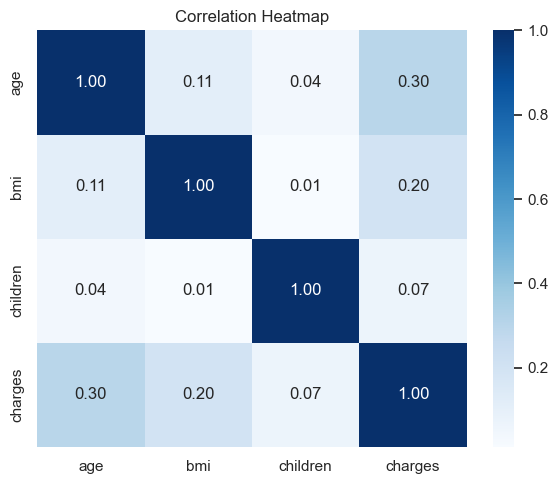

In [15]:
corr = df[numeric_columns].corr(numeric_only=True)
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()

Age and BMI show moderate positive relationships with charges, while the strongest impact is observed for smoking status.

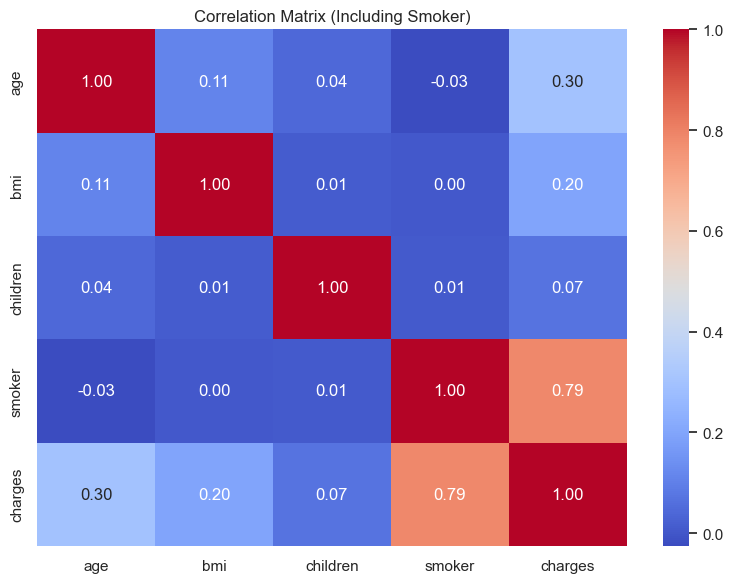

In [20]:
df_encoded = df.copy()
df_encoded["smoker"] = df_encoded["smoker"].map({"yes": 1, "no": 0})

corr = df_encoded.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix (Including Smoker)")
plt.tight_layout()
plt.show()

The correlation matrix including smoking status shows that `smoker` has the strongest relationship with insurance charges, with a correlation of 0.79. This supports the earlier visual analysis that smokers tend to incur substantially higher medical costs than non-smokers.

Age and BMI show weaker positive relationships with charges, while the number of children has minimal association. Overall, smoking status appears to be the most influential predictor of insurance cost in this dataset.

## Cleaning

In [17]:
clean_df = df.drop_duplicates().copy()
CLEAN_PATH.parent.mkdir(parents=True, exist_ok=True)
clean_df.to_csv(CLEAN_PATH, index=False)

print(f"Original rows: {len(df)}")
print(f"Clean rows: {len(clean_df)}")
print(f"Saved cleaned dataset to: {CLEAN_PATH}")

Original rows: 1338
Clean rows: 1337
Saved cleaned dataset to: /Users/rebeccarosettenanfuka/Desktop/MY-_PROJECTS/InsureRisk/data/processed/clean_data.csv


## Findings

- The dataset contains no missing values, indicating complete data for analysis.
- One duplicate record was identified and removed to ensure data quality.
- The distribution of insurance charges is highly right-skewed, with a small group of individuals incurring substantially higher costs.
- Smoking status has a strong impact on insurance charges, with smokers consistently showing higher costs than non-smokers.
- BMI is positively associated with insurance charges, although the relationship shows variability across individuals.
- A few high BMI outliers are present and may influence model performance if not handled carefully.

## Business Insights

- Smoking status is a major cost driver and could be used as a key factor in risk-based pricing or segmentation.
- Individuals with higher BMI may represent a higher-risk group, although additional factors also affect final charges.
- The skewed nature of charges suggests that classification into risk categories such as low, medium, and high cost could be more actionable than predicting raw charges alone.

## Next Steps

- Encode categorical variables for modeling
- Define a binary target variable for high-risk individuals
- Train and evaluate classification models
- Incorporate model explainability techniques (e.g., SHAP) to interpret predictions

## Limitations

- The dataset is relatively small and may not capture all real-world variability.
- External factors such as medical history or lifestyle are not included.